In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import os
import zipfile
import urllib.request
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_validate
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import os

PROJECT_DIR = "Student_Performance_Project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
PLOT_DIR = os.path.join(RESULT_DIR, "plots")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
import os
import urllib.request

# Direct CSV URL
CSV_URL = "https://raw.githubusercontent.com/sachanganesh/student-performance-prediction/master/data/student-mat.csv"

CSV_PATH = os.path.join(
    DATA_DIR,
    "student-mat.csv"
)

print("Checking for dataset...")

if os.path.exists(CSV_PATH):

    print("Dataset already exists!")
    print("Location:")
    print(CSV_PATH)

else:

    print("Dataset not found.")
    print("Downloading student-mat.csv...")

    urllib.request.urlretrieve(
        CSV_URL,
        CSV_PATH
    )

    print("Download completed!")

if os.path.exists(CSV_PATH):

    file_size = os.path.getsize(CSV_PATH)

    print("\n==============================================")
    print("DATASET SUCCESSFULLY DOWNLOADED!")
    print("==============================================")

    print("File:", CSV_PATH)

    print("File size:",
          round(file_size / 1024, 2),
          "KB")

else:

    print("\nERROR: Dataset could not be downloaded.")

Checking for dataset...
Dataset not found.
Download completed!

DATASET SUCCESSFULLY DOWNLOADED!
File: Student_Performance_Project/data/student-mat.csv
File size: 55.66 KB


In [ ]:
import pandas as pd
import os

# Check that the file exists
if not os.path.exists(CSV_PATH):

    raise FileNotFoundError(
        "student-mat.csv was not found. "
        "Please run Cell 4 first."
    )

# Load CSV
df = pd.read_csv(
    CSV_PATH,
    sep=";"
)

print("==============================================")
print("DATASET LOADED SUCCESSFULLY!")
print("==============================================")

print("\nDataset shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 rows:")

display(df.head())

DATASET LOADED SUCCESSFULLY!

Dataset shape:
(395, 33)

Number of rows: 395
Number of columns: 33

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 395
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  rea

In [ ]:
print("Missing values in each column:\n")

missing_values = df.isnull().sum()

display(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:



,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Total missing values: 0


In [ ]:
display(df.describe())

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
TARGET = "G3"

print("Target variable:", TARGET)

print("\nTarget variable statistics:")
display(df[TARGET].describe())

print("\nTarget value distribution:")
display(df[TARGET].value_counts().sort_index())

Target variable: G3

Target variable statistics:


,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000



Target value distribution:


,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


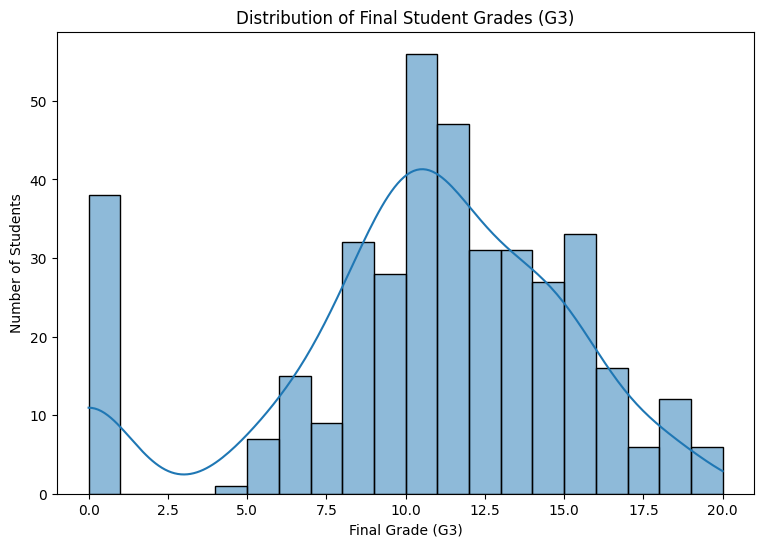

In [ ]:
plt.figure(figsize=(9, 6))

sns.histplot(
    df[TARGET],
    bins=20,
    kde=True
)

plt.title("Distribution of Final Student Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
X = df.drop(columns=[TARGET])

y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(TARGET)

Features shape: (395, 32)
Target shape: (395,)

Features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Target:
G3


In [ ]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

print("\nNumber of categorical columns:",
      len(categorical_columns))

print("Number of numerical columns:",
      len(numerical_columns))

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Number of categorical columns: 17
Number of numerical columns: 15


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (316, 32)
y_train: (316,)

Testing data:
X_test: (79, 32)
y_test: (79,)


In [ ]:
linear_regression_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

print("Linear Regression model created!")

Linear Regression model created!


In [ ]:
print("Training Linear Regression...")

linear_regression_model.fit(
    X_train,
    y_train
)

print("Linear Regression training completed!")

linear_predictions = linear_regression_model.predict(
    X_test
)

print("Predictions generated!")

Training Linear Regression...
Linear Regression training completed!
Predictions generated!


In [ ]:
decision_tree_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

print("Decision Tree model created!")

Decision Tree model created!


In [ ]:
print("Starting Decision Tree hyperparameter tuning...")
print("This may take some time...")

dt_parameters = {

    "model__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

dt_grid_search = GridSearchCV(

    estimator=decision_tree_model,

    param_grid=dt_parameters,

    cv=5,

    scoring="neg_mean_squared_error",

    n_jobs=-1,

    verbose=1
)

dt_grid_search.fit(
    X_train,
    y_train
)

print("\nDecision Tree tuning completed!")

print("\nBest Decision Tree parameters:")

print(dt_grid_search.best_params_)

Starting Decision Tree hyperparameter tuning...
This may take some time...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Decision Tree tuning completed!

Best Decision Tree parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}


In [ ]:
best_decision_tree = dt_grid_search.best_estimator_

decision_tree_predictions = best_decision_tree.predict(
    X_test
)

print("Best Decision Tree model ready!")

Best Decision Tree model ready!


In [ ]:
random_forest_model = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created!")

Random Forest model created!


In [ ]:
print("Starting Random Forest hyperparameter tuning...")
print("This may take some time...")

rf_parameters = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        10,
        20
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}

rf_grid_search = GridSearchCV(

    estimator=random_forest_model,

    param_grid=rf_parameters,

    cv=5,

    scoring="neg_mean_squared_error",

    n_jobs=-1,

    verbose=1
)

rf_grid_search.fit(
    X_train,
    y_train
)

print("\nRandom Forest tuning completed!")

print("\nBest Random Forest parameters:")

print(rf_grid_search.best_params_)

Starting Random Forest hyperparameter tuning...
This may take some time...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Random Forest tuning completed!

Best Random Forest parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [ ]:
best_random_forest = rf_grid_search.best_estimator_

random_forest_predictions = best_random_forest.predict(
    X_test
)

print("Best Random Forest model ready!")

Best Random Forest model ready!


In [ ]:
def evaluate_model(
    model_name,
    actual_values,
    predicted_values
):

    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    r2 = r2_score(
        actual_values,
        predicted_values
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


print("Evaluation function created!")

Evaluation function created!


In [ ]:
results = []

# Linear Regression
results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

# Decision Tree
results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions
    )
)

# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_predictions
    )
)

comparison_df = pd.DataFrame(results)

print("MODEL COMPARISON")
print("=" * 70)

display(
    comparison_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Linear Regression,1.6467,2.3784,0.7241
1,Decision Tree,1.4395,2.5793,0.6756
2,Random Forest,1.2118,2.0287,0.7993


In [ ]:
best_model_row = comparison_df.loc[
    comparison_df["RMSE"].idxmin()
]

best_model_name = best_model_row["Model"]

print("Best model based on lowest RMSE:")
print(best_model_name)

print("\nPerformance:")

print(
    "MAE  :",
    round(best_model_row["MAE"], 4)
)

print(
    "RMSE :",
    round(best_model_row["RMSE"], 4)
)

print(
    "R²   :",
    round(best_model_row["R2"], 4)
)

Best model based on lowest RMSE:
Random Forest

Performance:
MAE  : 1.2118
RMSE : 2.0287
R²   : 0.7993


In [ ]:
print("Starting 5-fold cross-validation...")

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {

    "MAE": "neg_mean_absolute_error",

    "RMSE": "neg_root_mean_squared_error",

    "R2": "r2"
}

models_for_cv = {

    "Linear Regression":
        linear_regression_model,

    "Decision Tree":
        best_decision_tree,

    "Random Forest":
        best_random_forest
}

cv_results = []

for model_name, model in models_for_cv.items():

    print("\nEvaluating:", model_name)

    scores = cross_validate(

        model,

        X,

        y,

        cv=kf,

        scoring=scoring,

        n_jobs=-1
    )

    cv_results.append({

        "Model": model_name,

        "CV_MAE_Mean":
            -scores["test_MAE"].mean(),

        "CV_MAE_STD":
            scores["test_MAE"].std(),

        "CV_RMSE_Mean":
            -scores["test_RMSE"].mean(),

        "CV_RMSE_STD":
            scores["test_RMSE"].std(),

        "CV_R2_Mean":
            scores["test_R2"].mean(),

        "CV_R2_STD":
            scores["test_R2"].std()
    })


cv_df = pd.DataFrame(cv_results)

print("\n5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_df.style.format({
        "CV_MAE_Mean": "{:.4f}",
        "CV_MAE_STD": "{:.4f}",
        "CV_RMSE_Mean": "{:.4f}",
        "CV_RMSE_STD": "{:.4f}",
        "CV_R2_Mean": "{:.4f}",
        "CV_R2_STD": "{:.4f}"
    })
)

Starting 5-fold cross-validation...

Evaluating: Linear Regression

Evaluating: Decision Tree

Evaluating: Random Forest

5-FOLD CROSS-VALIDATION RESULTS


,Model,CV_MAE_Mean,CV_MAE_STD,CV_RMSE_Mean,CV_RMSE_STD,CV_R2_Mean,CV_R2_STD
0,Linear Regression,1.3783,0.1647,2.0567,0.1765,0.7916,0.0422
1,Decision Tree,1.0579,0.2502,1.8757,0.5001,0.8113,0.0982
2,Random Forest,1.0269,0.1384,1.6176,0.3338,0.8665,0.0571


In [ ]:
final_comparison = comparison_df.merge(
    cv_df,
    on="Model"
)

print("FINAL MODEL COMPARISON")
print("=" * 100)

display(
    final_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
        "CV_MAE_Mean": "{:.4f}",
        "CV_MAE_STD": "{:.4f}",
        "CV_RMSE_Mean": "{:.4f}",
        "CV_RMSE_STD": "{:.4f}",
        "CV_R2_Mean": "{:.4f}",
        "CV_R2_STD": "{:.4f}"
    })
)

FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2,CV_MAE_Mean,CV_MAE_STD,CV_RMSE_Mean,CV_RMSE_STD,CV_R2_Mean,CV_R2_STD
0,Linear Regression,1.6467,2.3784,0.7241,1.3783,0.1647,2.0567,0.1765,0.7916,0.0422
1,Decision Tree,1.4395,2.5793,0.6756,1.0579,0.2502,1.8757,0.5001,0.8113,0.0982
2,Random Forest,1.2118,2.0287,0.7993,1.0269,0.1384,1.6176,0.3338,0.8665,0.0571


In [ ]:
evaluation_path = os.path.join(
    RESULT_DIR,
    "evaluation_comparison.csv"
)

final_comparison.to_csv(
    evaluation_path,
    index=False
)

print("Evaluation table saved at:")

print(evaluation_path)

Evaluation table saved at:
Student_Performance_Project/results/evaluation_comparison.csv


In [ ]:
rf_preprocessor = (
    best_random_forest
    .named_steps["preprocessor"]
)

rf_model = (
    best_random_forest
    .named_steps["model"]
)

# Get transformed feature names
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Clean feature names
feature_names = [
    name
    .replace("numerical__", "")
    .replace("categorical__", "")
    for name in feature_names
]

# Get importance
importance_values = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_values

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("Top 20 important features:")

display(
    feature_importance_df.head(20)
)

Top 20 important features:


,Feature,Importance
14,G2,0.792433
12,absences,0.109640
36,reason_home,0.019318
0,age,0.010206
13,G1,0.005927
6,famrel,0.004590
35,reason_course,0.004201
8,goout,0.003919
11,health,0.003511
4,studytime,0.003456


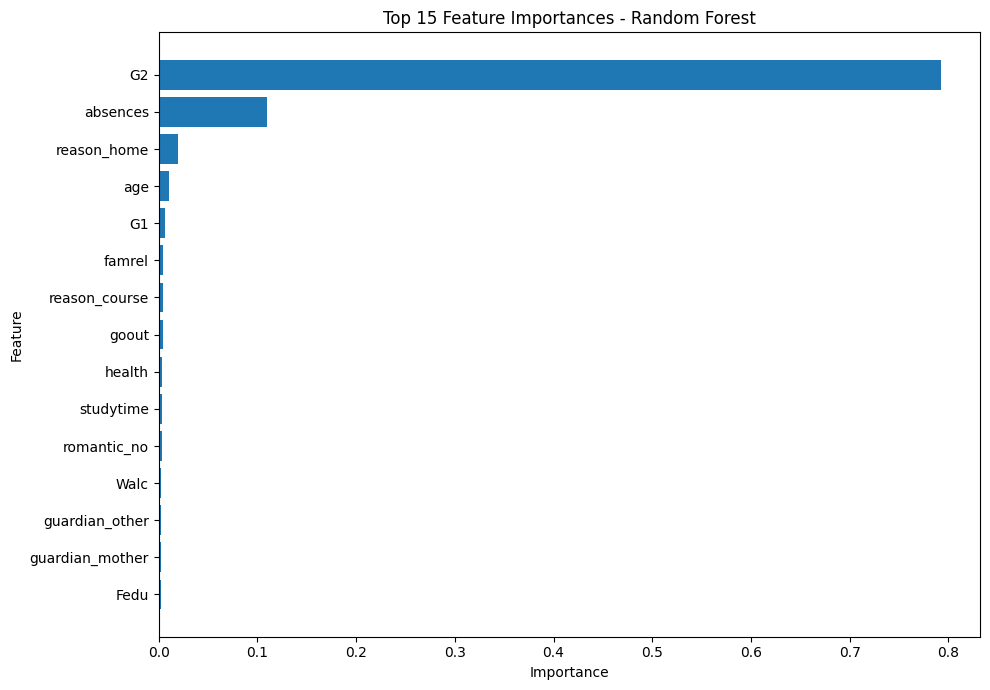

Feature importance graph saved at:
Student_Performance_Project/results/plots/feature_importance.png


In [ ]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importances - Random Forest"
)

plt.tight_layout()

feature_plot_path = os.path.join(
    PLOT_DIR,
    "feature_importance.png"
)

plt.savefig(
    feature_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance graph saved at:")
print(feature_plot_path)

In [ ]:
feature_importance_path = os.path.join(
    RESULT_DIR,
    "feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance table saved at:")
print(feature_importance_path)

Feature importance table saved at:
Student_Performance_Project/results/feature_importance.csv


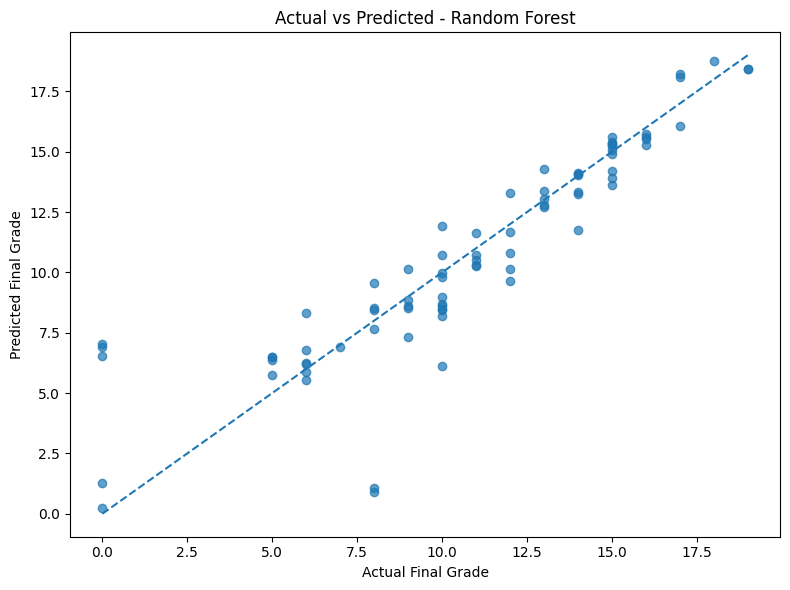

Actual vs Predicted graph saved at:
Student_Performance_Project/results/plots/actual_vs_predicted.png


In [ ]:
prediction_dictionary = {

    "Linear Regression":
        linear_predictions,

    "Decision Tree":
        decision_tree_predictions,

    "Random Forest":
        random_forest_predictions
}

best_predictions = prediction_dictionary[
    best_model_name
]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

minimum_value = min(
    y_test.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.tight_layout()

actual_predicted_path = os.path.join(
    PLOT_DIR,
    "actual_vs_predicted.png"
)

plt.savefig(
    actual_predicted_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Actual vs Predicted graph saved at:")
print(actual_predicted_path)

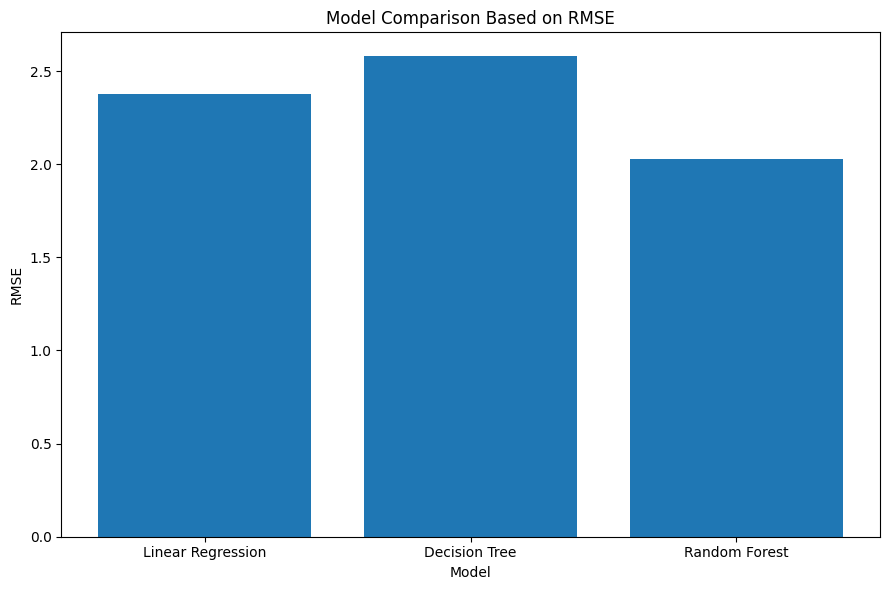

RMSE comparison graph saved at:
Student_Performance_Project/results/plots/model_rmse_comparison.png


In [ ]:
plt.figure(figsize=(9, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.title(
    "Model Comparison Based on RMSE"
)

plt.xticks(rotation=0)

plt.tight_layout()

rmse_plot_path = os.path.join(
    PLOT_DIR,
    "model_rmse_comparison.png"
)

plt.savefig(
    rmse_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("RMSE comparison graph saved at:")
print(rmse_plot_path)

In [ ]:
linear_model_path = os.path.join(
    MODEL_DIR,
    "linear_regression_model.joblib"
)

decision_tree_model_path = os.path.join(
    MODEL_DIR,
    "decision_tree_model.joblib"
)

random_forest_model_path = os.path.join(
    MODEL_DIR,
    "random_forest_model.joblib"
)


joblib.dump(
    linear_regression_model,
    linear_model_path
)

joblib.dump(
    best_decision_tree,
    decision_tree_model_path
)

joblib.dump(
    best_random_forest,
    random_forest_model_path
)


print("All trained models saved successfully!")

print("\nSaved models:")

print(linear_model_path)
print(decision_tree_model_path)
print(random_forest_model_path)

All trained models saved successfully!

Saved models:
Student_Performance_Project/models/linear_regression_model.joblib
Student_Performance_Project/models/decision_tree_model.joblib
Student_Performance_Project/models/random_forest_model.joblib


In [ ]:
dataset_summary = pd.DataFrame({

    "Property": [

        "Dataset Rows",

        "Dataset Columns",

        "Target Variable",

        "Training Samples",

        "Testing Samples",

        "Numerical Features",

        "Categorical Features"

    ],

    "Value": [

        df.shape[0],

        df.shape[1],

        TARGET,

        X_train.shape[0],

        X_test.shape[0],

        len(numerical_columns),

        len(categorical_columns)

    ]

})

display(dataset_summary)

summary_path = os.path.join(
    RESULT_DIR,
    "dataset_summary.csv"
)

dataset_summary.to_csv(
    summary_path,
    index=False
)

print("Dataset summary saved at:")
print(summary_path)

,Property,Value
0,Dataset Rows,395
1,Dataset Columns,33
2,Target Variable,G3
3,Training Samples,316
4,Testing Samples,79
5,Numerical Features,15
6,Categorical Features,17


Dataset summary saved at:
Student_Performance_Project/results/dataset_summary.csv


In [ ]:
best_row = final_comparison.loc[
    final_comparison["RMSE"].idxmin()
]

best_model = best_row["Model"]

report = f"""

============================================================
        STUDENT PERFORMANCE PREDICTION MODEL
             FINAL RECOMMENDATION REPORT
============================================================

1. PROJECT TITLE
Student Performance Prediction Model


2. OBJECTIVE
The objective of this project is to develop and compare
machine learning models for predicting student academic
performance.


3. DATASET
Dataset: UCI Student Performance Dataset

Target Variable: G3

G3 represents the student's final grade.


4. MACHINE LEARNING MODELS

The following regression models were trained:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor


5. HYPERPARAMETER TUNING

GridSearchCV was applied to:

- Decision Tree
- Random Forest

The best hyperparameters were selected using 5-fold
cross-validation.


6. EVALUATION METRICS

The models were evaluated using:

MAE  = Mean Absolute Error

RMSE = Root Mean Squared Error

R2   = R-squared


7. TEST SET RESULTS

{final_comparison[
    ["Model", "MAE", "RMSE", "R2"]
].to_string(index=False)}


8. 5-FOLD CROSS-VALIDATION RESULTS

{cv_df.to_string(index=False)}


9. RECOMMENDED MODEL

The model with the lowest test-set RMSE is:

{best_model}


10. BEST MODEL PERFORMANCE

MAE  : {best_row["MAE"]:.4f}

RMSE : {best_row["RMSE"]:.4f}

R2   : {best_row["R2"]:.4f}


11. INTERPRETATION

MAE measures the average absolute difference between the
actual and predicted grades.

RMSE gives greater importance to larger prediction errors.

R2 indicates how much variation in student final grades
is explained by the model.

Therefore, a lower MAE and RMSE are desirable, while a
higher R2 is desirable.


12. FEATURE IMPORTANCE

Random Forest feature importance was used to identify
the input variables that contributed most strongly to
the prediction.

The complete feature importance table is available in:

results/feature_importance.csv


13. CONCLUSION

Three machine learning models were successfully trained
and compared for student performance prediction.

GridSearchCV was used for hyperparameter tuning and
5-fold cross-validation was performed to evaluate model
stability.

Based on the test-set RMSE, the recommended model is:

{best_model}

The generated evaluation table and visualizations can be
used in the final project report.


============================================================
END OF REPORT
============================================================
"""

report_path = os.path.join(
    RESULT_DIR,
    "final_recommendation_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print(report)

print("\nReport saved at:")
print(report_path)



        STUDENT PERFORMANCE PREDICTION MODEL
             FINAL RECOMMENDATION REPORT

1. PROJECT TITLE
Student Performance Prediction Model


2. OBJECTIVE
The objective of this project is to develop and compare
machine learning models for predicting student academic
performance.


3. DATASET
Dataset: UCI Student Performance Dataset

Target Variable: G3

G3 represents the student's final grade.


4. MACHINE LEARNING MODELS

The following regression models were trained:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor


5. HYPERPARAMETER TUNING

GridSearchCV was applied to:

- Decision Tree
- Random Forest

The best hyperparameters were selected using 5-fold
cross-validation.


6. EVALUATION METRICS

The models were evaluated using:

MAE  = Mean Absolute Error

RMSE = Root Mean Squared Error

R2   = R-squared


7. TEST SET RESULTS

            Model      MAE     RMSE       R2
Linear Regression 1.646666 2.378370 0.724134
    Decision Tree 1.439520 2.579305 0.

In [ ]:
import shutil

zip_file = shutil.make_archive(
    "Student_Performance_AI_Final_Project",
    "zip",
    PROJECT_DIR
)

print("ZIP file created successfully!")

print(zip_file)

# Download to your computer
from google.colab import files

files.download(zip_file)

ZIP file created successfully!
/content/Student_Performance_AI_Final_Project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>